# LVM DR20 model-file tutorial: reading and visualizing reconstructed spectral components

This notebook shows how to read an LVM DR20 DAP **model file** for the Helix Nebula example exposure and how to visualize the different spectral components stored in it. The model file complements the standard DAP table: instead of storing scalar measurements per fiber, it stores spectra reconstructed from the DAP analysis, including the observed spectrum, stellar-continuum model, gas-emission models, joint models, and residual products.

The tutorial follows the same dataset convention used in the DR20 Helix notebooks: `DRPVER=1.2.0`, `DAPVER=1.2.0.251218`, `MJD=60191`, and `EXPNUM=00004297`. The goal is to inspect the model products and understand how they relate to the DAP decomposition.

In [1]:
__author__ = 'Sebastian F. Sanchez and LVM team'
__version__ = '20260420'
__datasets__ = ['SDSS-V LVM DAP (DRPVER=1.2.0, DAPVER = 1.2.0.251218, MJD=60191, EXPNUM=4297)']  
__keywords__ = ['Helix nebula','LVM','DR20','model spectra','tutorial']

## 1. Notebook metadata

This cell records the authorship, version, dataset, and keywords for the tutorial. These variables do not affect the analysis directly, but they document the provenance of the notebook and make clear which DR20 example dataset is being used.

In [31]:
#
# We use one single thread to avoid problems with the use of multiple threads in some of the used libraries, which can cause problems when running in parallel with multiprocessing.
#
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from pathlib import Path
import numpy as np

from astropy.table import Table,join
from astropy.io import fits
from sdss_access import Access
from pathlib import Path
import os
import matplotlib.pyplot as plt
import math
from pprint import pprint
from astropy.convolution import convolve
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d,median_filter
from numpy.polynomial.legendre import Legendre
from matplotlib.ticker import MultipleLocator

from sdss_access import Access
access = Access(release='dr20', verbose=True)

## 2. Imports, plotting tools, and SDSS access

This cell imports the numerical, FITS, plotting, interpolation, smoothing, and SDSS-access utilities used throughout the notebook. It also initializes `sdss_access` for the `dr20` release. The notebook uses `sdss_access` to locate the model file whenever possible, while later cells include a local patch for cases where the model file has already been generated or downloaded into a local directory.

The thread-control environment variables are set before the heavy numerical imports to reduce the risk of oversubscription when running on systems where BLAS/OpenMP libraries use many threads by default.

In [13]:
drpver = "1.2.0"
dapver = '1.2.0.251218' 
DIR_CACHE = 'cache/'
if not os.path.isdir(DIR_CACHE):
    os.mkdir(DIR_CACHE)
DRVER = 'DR20'
DIR_DAP = 'dap_v1.2.0/'
DIR_FIG = 'figs/'
tilegrp = '0011XX'
tileid = '11111'
mjd = '60191'
expnum = '00004297'
mjd = 60191
rsp = 'rsp108'
sn = 'sn20'
i_expnum = int(expnum)
dap_model_file = f'dap-{rsp}-{sn}-{expnum}.model.fits'

## 3. Define the DR20 Helix dataset and local directories

This cell defines the DRP/DAP versions, exposure identifiers, local cache/figure directories, and the expected name of the model FITS file. The key product here is `dap_model_file`, which follows the convention `dap-rsp108-sn20-EXPNUM.model.fits`.

**Important note:** keep `mjd` as a string if it is later used to build paths with `pathlib.Path`. Reassigning `mjd` to an integer may cause path-construction errors in other cells.

In [14]:
# try:
    ##################################################
    # (1.1) Get the data using the sdss_access pachage
    ##################################################
path_to_data_file = access.full('lvm_model',  drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
if not os.path.isfile(path_to_data_file):
    access.remote()
    kind = 'dap'    
    access.add('lvm_model', drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
    access.set_stream()
    access.commit()
    # PATH to lvmDAP file
    path_to_data_file = access.full('lvm_model',  drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
    # print(path_to_data_file)
    # Open data file and print a summary of the Header Data Units
dap_model_file = path_to_data_file
# except:
#     ################################################################
#     # (1.2) Get the data from a local directory
#     ################################################################
#     dap_file=f'dap-{rsp}-{sn}-{expnum}.dap.fits.gz'
#     dap_file=f'{DIR_DAP}/{dap_file}'



[ERROR]: Traceback (most recent call last):
  File "/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_344290/1869706172.py", line 5, in <module>
    path_to_data_file = access.full('lvm_model',  drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sanchez/.local/lib/python3.11/site-packages/sdss_access/path/path.py", line 706, in full
    assert filetype in self.templates, ('No entry {0} found. Filetype must '
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: No entry lvm_model found. Filetype must be one of the designated templates in the currently loaded tree



## 4. Locate the model file using `sdss_access`

This cell asks `sdss_access` for the location of the `lvm_model` product corresponding to the selected DR20 exposure. If the file is not already present locally, the cell attempts to download it through the SDSS access system.

The resolved path is stored in `dap_model_file`. This is the preferred access route when the SDSS tree configuration is available and correctly configured.

In [20]:
#
# Local Patch
#
dap_model_file = f'{DIR_DAP}/dap-{rsp}-{sn}-{expnum}.model.fits'

## 5. Local-path override

This cell overrides the `sdss_access` path and points directly to a local model file in `DIR_DAP`. This is useful when working with locally generated model files or when the SDSS product resolution is not available in the current environment.

Use this cell intentionally: if you want to rely on the `sdss_access` result from the previous cell, comment out this local patch.

In [27]:
hdu_outmod = fits.open(dap_model_file)
print(hdu_outmod.info())
cube = hdu_outmod[0].data
wave = hdu_outmod[0].header['CRVAL1'] + np.arange(hdu_outmod[0].header['NAXIS1'])*hdu_outmod[0].header['CDELT1']
dap_fwhm = 1.0
f_scale=1e16
hdu_outmod[0].header


Filename: dap_v1.2.0//dap-rsp108-sn20-00004297.model.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (12401, 1754, 9)   float32   
None


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                12401                                                  
NAXIS2  =                 1754                                                  
NAXIS3  =                    9                                                  
EXTEND  =                    T                                                  
PIPELINE= 'pyPipe3D v1.1.5'                                                     
UNIXTIME=           1769692726 / 2026-01-29 07:18:46.233775                     
CRPIX1  =                    1                                                  
CRVAL1  =               3600.0                                                  
CDELT1  =                  0.5                                                  
NAME0   = 'org_spec'        

## 6. Open the model FITS file and extract the model cube

This cell opens the model FITS file, prints its FITS structure, and extracts:

- `cube`: the 3D model array,
- `wave`: the wavelength solution reconstructed from the FITS header,
- `f_scale`: the flux scaling used for plotting.

The model cube is organized as:

- axis 0: model component,
- axis 1: fiber index,
- axis 2: wavelength pixel.

The header keywords `NAME0`, `NAME1`, ..., `NAME8` identify the physical meaning of each component plane.

(6500.0, 6740.0)

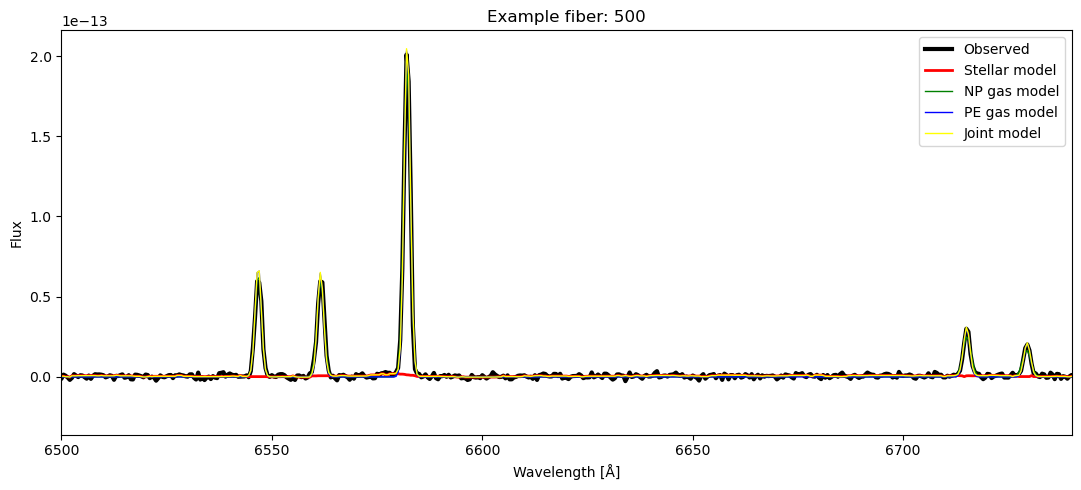

In [28]:
fib = 500
%matplotlib inline
plt.figure(figsize=(11, 5))
plt.plot(wave, cube[0, fib, :], label="Observed", lw=3, color="black")
plt.plot(wave, cube[1, fib, :], label="Stellar model", lw=2, color="red")
plt.plot(wave, cube[6, fib, :], label="NP gas model", lw=1, color="green")
plt.plot(wave, cube[7, fib, :], label="PE gas model", lw=1, color="blue")
plt.plot(wave, cube[2, fib, :], label="Joint model", lw=1, color="yellow")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title(f"Example fiber: {fib}")
plt.legend()
plt.tight_layout()
plt.xlim(6500, 6740)
#plt.show()

## 7. Inspect one fiber in the Hα spectral region

This cell selects one representative fiber and plots several model components around the Hα+[N II]+[S II] spectral region. The plotted components are:

- `cube[0]`: observed spectrum,
- `cube[1]`: stellar model,
- `cube[6]`: non-parametric gas model,
- `cube[7]`: parametric emission-line model,
- `cube[2]`: joint model.

This comparison is a direct diagnostic of how the model file decomposes the observed spectrum into stellar and nebular components. In a nebular target such as the Helix, the gas model dominates the strong-line windows, while the stellar model is usually weak except in fibers containing foreground or field stars.

In [46]:
av_spec = np.nanmean(cube, axis=1)
print(av_spec.shape) 

(9, 12401)


## 8. Compute average spectra over the field

This cell collapses the model cube along the fiber axis, producing `av_spec`, the average spectrum for each stored model component. This is useful for a global quick-look view of the exposure and for comparing model components in a high-S/N average spectrum.

The resulting array has shape `(Ncomponent, Nwave)`.

(-5e-15, 1.3e-13)

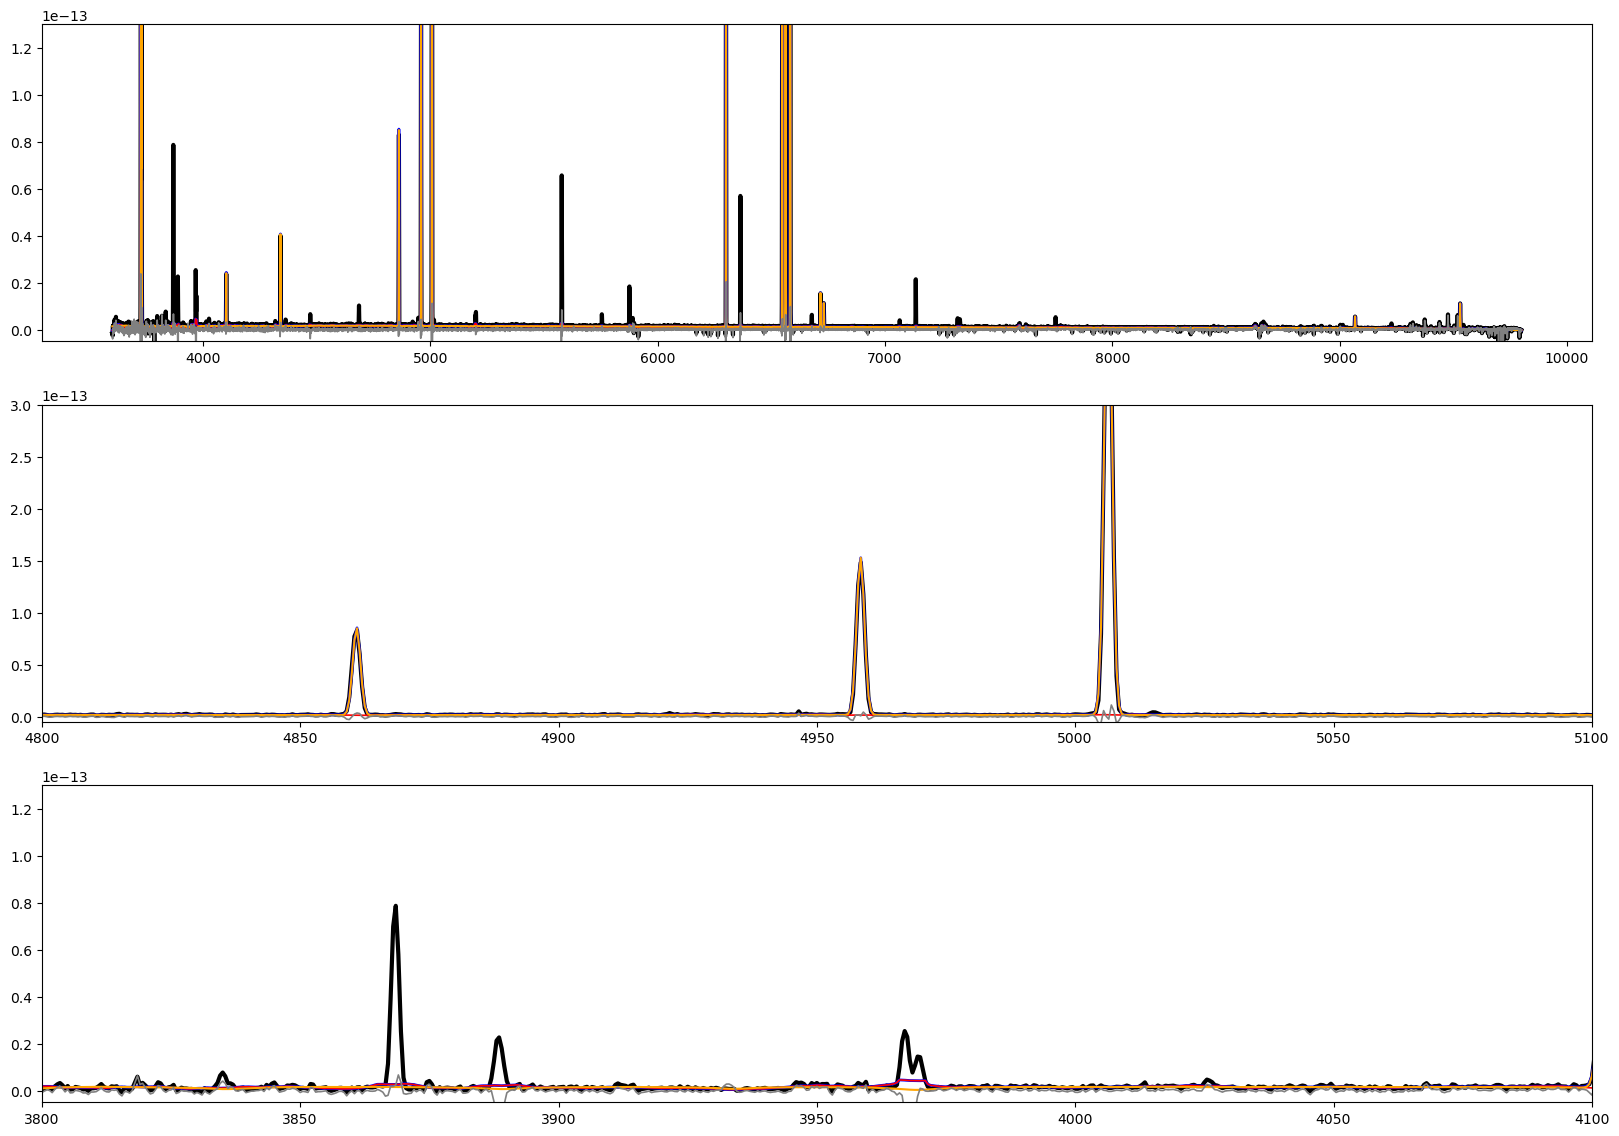

In [47]:
##################################################################################
# We plot the average spectra and the average model spectra
##################################################################################

%matplotlib inline
fig, ax = plt.subplots(3, 1, figsize=(20, 14))
#plt.imshow(model_spectra[7, :, :], aspect='auto', origin='lower')

for ax_now in ax.flatten():
    ax_now.plot(wave, av_spec[0,:],color='black',linewidth=3)
    ax_now.plot(wave, av_spec[2,:],color='blue',linewidth=2,alpha=1.0)
#    ax_now.plot(wave, np.nanmean(model_spectra[6, :, :],axis=0),color='blue',linewidth=1.5)
#    ax_now.plot(wave, np.nanmean(model_spectra[7, :, :],axis=0),color='darkblue',linewidth=1.5)
    ax_now.plot(wave, av_spec[1,:],color='red',linewidth=1.2)
    ax_now.plot(wave, av_spec[8,:],color='orange',linewidth=1.5,alpha=1.0)
    ax_now.plot(wave, av_spec[4,:],color='grey',linewidth=1.2)
#ax[0].set_xlim(3800, 4100)
ax[0].set_ylim(-50/f_scale, 1300/f_scale)

ax[1].set_xlim(4800, 5100)
ax[1].set_ylim(-50/f_scale, 3000/f_scale)

ax[2].set_xlim(3800, 4100)
ax[2].set_ylim(-50/f_scale, 1300/f_scale)
#plt.show()

## 9. Plot average observed and model spectra in selected wavelength ranges

This cell compares the average observed spectrum with the average model components in several wavelength windows. The figure is useful for checking whether the joint model reproduces the strong emission lines and continuum shape, and whether the residuals remain close to zero.

The three panels focus on selected spectral ranges, including the blue region and prominent optical emission-line windows. This is a compact quality-control view of the model file.

In [90]:
def gamma_scale_test(flux,gamma):
    return flux

def gamma_scale(flux,gamma):
    return (flux/np.abs(flux))*(np.abs(flux))**gamma

def gamma_scale_abs(flux,gamma):
    return (np.abs(flux))**gamma

def my_medfilt (x, k):
    """Apply a length-k median filter to a 1D array x.
    Boundaries are extended by repeating endpoints.
    """
    import numpy as np

    assert k % 2 == 1, "Median filter length must be odd."
    assert x.ndim == 1, "Input must be one-dimensional."
    
    k2 = (k - 1) // 2
    y = np.zeros ((len (x), k), dtype=x.dtype)
    y[:,k2] = x
    for i in range (k2):
        j = k2 - i
        y[j:,i] = x[:-j]
        y[:j,i] = x[0]
        y[:-j,-(i+1)] = x[j:]
        y[-j:,-(i+1)] = x[-1]
    return np.median (y, axis=1)


def my_meanfilt (x, k):
    """Apply a length-k mean filter to a 1D array x.
    Boundaries are extended by repeating endpoints.
    """
    
    import numpy as np

    assert k % 2 == 1, "Median filter length must be odd."
    assert x.ndim == 1, "Input must be one-dimensional."
    
    k2 = (k - 1) // 2
    y = np.zeros ((len (x), k), dtype=x.dtype)
    y[:,k2] = x
    for i in range (k2):
        j = k2 - i
        y[j:,i] = x[:-j]
        y[:j,i] = x[0]
        y[:-j,-(i+1)] = x[j:]
        y[-j:,-(i+1)] = x[-1]
    return np.mean (y, axis=1)



def plot_spec_now_3pg(
    data_2d,
    wave=None,
    *,
    crval=None,
    cdelt=None,
    crpix=None,
    name='none',
    cmap=None,
    x_min=(3600, 3600, 3600),
    x_max=(9600, 9600, 9600),
    y_min=-0.2,
    y_max=2,
    text='',
    no_st=False,
    no_model=False,
    log=False,
    id_lines=None,
    output='junk.pdf',
    c_map='carlos',
    do_legend=True,
    insets=None,
    y0_d=0.5,
    y1_d=2.5,
    plot_el=False,
    tab_el=None,
    colors_in=('black', 'red', 'deepskyblue', 'blue', 'gold', 'forestgreen'),
    plot_res=False,
    show_scale=True,
    n_ord=11,
    gamma=0.3,
    props=None,
    alpha=0.5,
    SN_sc_lim=3,
    ):

    if props is None:
        props = dict(facecolor='lightgrey', alpha=0.5, edgecolor='darkgrey')

    data = np.asarray(data_2d, dtype=float)
    if data.ndim != 2:
        raise ValueError("data_2d must be a 2D array with shape (ny, nx).")

    ny, nx = data.shape

    if wave is None:
        if crval is None or cdelt is None or crpix is None:
            raise ValueError(
                "Provide either 'wave' or all of 'crval', 'cdelt', and 'crpix'."
            )
        wave = crval + cdelt * (np.arange(nx) - (crpix - 1))
    else:
        wave = np.asarray(wave, dtype=float)
        if wave.ndim != 1 or wave.shape[0] != nx:
            raise ValueError("wave must be a 1D array with length equal to data_2d.shape[1].")

    if cmap is None:
        cmap = 'Spectral'

    i0 = int(nx * 0.15)
    i1 = int(nx * 0.25)

    med_sc = np.abs(np.nanmedian(data[0, i0:i1]))
    std_sc = np.nanstd(data[0, i0:i1])
    SN_sc = med_sc / std_sc if std_sc != 0 else np.inf
    print(f'# S/N: {SN_sc} {med_sc} {std_sc}')

    if med_sc == 0 or not np.isfinite(med_sc):
        raise ValueError("Normalization median is zero or invalid.")

    data = data / med_sc

    smooth = np.zeros(nx, dtype=float)



    ssp_model = data[1]

    fig = plt.figure(figsize=(19, 19))
    gs = fig.add_gridspec(
        nrows=10,
        ncols=12,
        left=0.175,
        right=0.97,
        hspace=0.35,
        wspace=0.05,
        bottom=0.15,
        top=0.9,
    )

    ax2 = fig.add_subplot(gs[8:10, :])
    ax0 = fig.add_subplot(gs[0:2, :])
    ax0m = fig.add_subplot(gs[2:4, :])
    ax0u = fig.add_subplot(gs[4:6, :])

    ax2.set_xticks([])
    ax2.set_yticks([])
    plt.setp(ax2.spines.values(), color=None)

    ax0.set_xlim(x_min[0], x_max[0])
    ax0m.set_xlim(x_min[1], x_max[1])
    ax0u.set_xlim(x_min[2], x_max[2])

    sign = 1 if y_min >= 0 else -1
    ax0.set_ylim(sign * np.abs(y_min**gamma), y_max**gamma)
    ax0u.set_ylim(sign * np.abs(y_min**gamma), y_max**gamma)
    ax0m.set_ylim(sign * np.abs(y_min**gamma), y_max**gamma)

    colors = list(colors_in)
    res = data[4] 
    gas_model = data[7]

    #NAME0   = 'org_spec'                                                            
    #NAME1   = 'model_spec'                                                          
    #NAME2   = 'mod_joint_spec'                                                      
    #NAME3   = 'gas_spec'                                                            
    #NAME4   = 'res_joint_spec'                                                      
    #NAME5   = 'no_gas_spec'                                                         
    #NAME6   = 'gas_model_NP'                                                        
    #NAME7   = 'gas_model_PEK'                                                       
    #NAME8   = 'mod_joint_spec_PEK'  

    if not no_st:
        ax0.plot(
            wave,
            gamma_scale(data[0, :], gamma),
            color=colors[0],
            alpha=1.0,
            linewidth=3.0,
            label=r'Obs. Spectrum (O$_\lambda$)',
        )
        ax0u.plot(
            wave,
            gamma_scale(data[0, :], gamma),
            color=colors[0],
            alpha=1.0,
            linewidth=3.0,
            label=r'Obs. Spectrum (O$_\lambda$)',
        )
        ax0m.plot(
            wave,
            gamma_scale(data[0, :], gamma),
            color=colors[0],
            alpha=1.0,
            linewidth=3.0,
            label=r'Obs. Spectrum (O$_\lambda$)',
        )

        if not no_model:
            ax0.plot(
                wave,
                gamma_scale(ssp_model, gamma),
                color=colors[1],
                alpha=alpha,
                linewidth=1.5,
                label=r'St. Model (M$_\lambda$)',
                linestyle='solid',
            )
            ax0u.plot(
                wave,
                gamma_scale(ssp_model, gamma),
                color=colors[1],
                alpha=alpha,
                linewidth=1.5,
                label=r'St. Model (M$_\lambda$)',
                linestyle='solid',
            )
            ax0m.plot(
                wave,
                gamma_scale(ssp_model, gamma),
                color=colors[1],
                alpha=alpha,
                linewidth=1.5,
                label=r'St. Model (M$_\lambda$)',
                linestyle='solid',
            )

    ax0.plot(
        wave,
        gamma_scale(data[0, :] + smooth, gamma) - gamma_scale(data[1, :], gamma),
        color=colors[2],
        alpha=alpha,
        label=r'St. Residual (O$_\lambda$-M$_\lambda$)',
        linewidth=3,
    )
    ax0u.plot(
        wave,
        gamma_scale(data[0, :] + smooth, gamma) - gamma_scale(data[1, :], gamma),
        color=colors[2],
        alpha=alpha,
        label=r'St. Residual (O$_\lambda$-M$_\lambda$)',
        linewidth=3,
    )
    ax0m.plot(
        wave,
        gamma_scale(data[0, :] + smooth, gamma) - gamma_scale(data[1, :], gamma),
        color=colors[2],
        alpha=alpha,
        label=r'St. Residual (O$_\lambda$-M$_\lambda$)',
        linewidth=3,
    )

    if not no_model:
        ax0.plot(
            wave,
            gamma_scale(data[2, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[3],
            alpha=alpha,
            linewidth=1.5,
            label=r'Em. Lines model (E$_\lambda$)',
            linestyle='solid',
        )
        ax0u.plot(
            wave,
            gamma_scale(data[2, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[3],
            alpha=alpha,
            linewidth=1.5,
            label=r'Em. Lines model (E$_\lambda$)',
            linestyle='solid',
        )
        ax0m.plot(
            wave,
            gamma_scale(data[2, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[3],
            alpha=alpha,
            linewidth=1.5,
            label=r'Em. Lines model (E$_\lambda$)',
            linestyle='solid',
        )

    if plot_res:
        ax0.plot(
            wave,
            gamma_scale(data[1, :] + data[4, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[4],
            alpha=alpha,
            linewidth=1.5,
            label=r'Final residual (R$_\lambda$)',
            linestyle='solid',
        )
        ax0m.plot(
            wave,
            gamma_scale(data[1, :] + data[4, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[4],
            alpha=alpha,
            linewidth=1.5,
            label=r'Final residual (R$_\lambda$)',
            linestyle='solid',
        )
        ax0u.plot(
            wave,
            gamma_scale(data[1, :] + data[4, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[4],
            alpha=alpha,
            linewidth=1.5,
            label=r'Final residual (R$_\lambda$)',
            linestyle='solid',
        )

    _std_res = np.std(res[2000:2500]) if nx > 2500 else np.std(res)
    _flux = np.median(data[1, 2000:2500]) if nx > 2500 else np.median(data[1, :])

    ax0.xaxis.set_minor_locator(MultipleLocator(100))
    handles, labels = ax0.get_legend_handles_labels()
    if do_legend:
        ax0.legend(
            handles,
            labels,
            loc=(-0.005, 1.01),
            frameon=True,
            handlelength=1.5,
            ncol=5,
            columnspacing=0.15,
            prop={'size': 22},
        )

    if id_lines is not None:
        mask_lines = (id_lines['wl'].value >= x_min[0]) & (id_lines['wl'].value < x_max[2])
        tab_elines = id_lines[mask_lines]
        even = 0
        for line in tab_elines:
            ax0.text(
                line['wl'],
                y_max - 0.16 * (even + 1) * (y_max - y_min),
                f"{line['wl']}",
                color=colors[even],
                fontsize=16,
                horizontalalignment='center',
                rotation='vertical',
            )
            even += 1
            if even > 2:
                even = 0

    if insets is not None:
        for i_inst, inst in enumerate(insets):
            axins = ax0.inset_axes(
                [inst[0], inst[1], inst[2], inst[3]],
                xlim=(inst[4], inst[5]),
                ylim=(inst[6], inst[7]),
                yticklabels=[],
            )
            if i_inst in (0, 9):
                axins.set_ylabel(r'Flux$_\lambda$', fontsize=23)

            if not no_st:
                axins.plot(
                    wave,
                    data[0, :],
                    color=colors[0],
                    alpha=1.0,
                    linewidth=3,
                    label=r'Observed (O$_\lambda$)',
                )
            if not no_model:
                axins.plot(
                    wave,
                    ssp_model,
                    color=colors[1],
                    alpha=1.0,
                    linewidth=1.5,
                    label=r'Model (M$_\lambda$)',
                    linestyle='solid',
                )
            axins.plot(
                wave,
                res,
                color=colors[2],
                alpha=1.0,
                linewidth=3,
                label=r'Residual (O$_\lambda$-M$_\lambda$)',
            )
            if not no_model:
                axins.plot(
                    wave,
                    gas_model,
                    color=colors[3],
                    alpha=1.0,
                    linewidth=1.5,
                    label=r'E. lines model',
                    linestyle='solid',
                )
            if plot_res:
                axins.plot(
                    wave,
                    data[4, :],
                    color=colors[4],
                    alpha=1.0,
                    linewidth=1.5,
                    label=r'Em. lines model (E$_\lambda$)',
                    linestyle='solid',
                )

            if plot_el:
                tab_el_now = tab_el[(tab_el['wl'] > inst[4]) & (tab_el['wl'] < inst[5])]
                for vals in tab_el_now:
                    axins.plot(
                        [vals['wl'], vals['wl']],
                        [
                            inst[7] - 0.05 * abs(inst[7] - inst[6]),
                            inst[7] - 0.15 * abs(inst[7] - inst[6]),
                        ],
                        color='darkorange',
                        linewidth=2,
                    )
                axins.text(
                    inst[4] + 0.1 * np.abs(inst[5] - inst[4]),
                    inst[7] - 0.15 * abs(inst[7] - inst[6]),
                    fr'\bf {inst[8]}',
                    bbox=props,
                )

    ax0.text(
        x_min[0] + 0.05 * (x_max[0] - x_min[0]),
        y_min + 0.85 * (y_max - y_min),
        text,
        fontsize=21,
    )
    ax0m.text(
        x_min[1] + 0.05 * (x_max[1] - x_min[1]),
        y_min + 0.85 * (y_max - y_min),
        text,
        fontsize=21,
    )
    ax0u.text(
        x_min[2] + 0.05 * (x_max[2] - x_min[2]),
        y_min + 0.85 * (y_max - y_min),
        text,
        fontsize=21,
    )

    ax2.set_xlabel(r'rest-frame wavelength [\AA]', fontsize=23)

    if plot_el and tab_el is not None:
        for vals in tab_el:
            ax0.plot(
                [vals['wl'], vals['wl']],
                [
                    y_max**gamma - 0.02 * abs(y_max**gamma - y_min**gamma),
                    y_max**gamma - 0.10 * abs(y_max**gamma - y_min**gamma),
                ],
                color='darkorange',
            )
            ax0u.plot(
                [vals['wl'], vals['wl']],
                [
                    y_max**gamma - 0.02 * abs(y_max**gamma - y_min**gamma),
                    y_max**gamma - 0.10 * abs(y_max**gamma - y_min**gamma),
                ],
                color='darkorange',
            )
            ax0m.plot(
                [vals['wl'], vals['wl']],
                [
                    y_max**gamma - 0.02 * abs(y_max**gamma - y_min**gamma),
                    y_max**gamma - 0.10 * abs(y_max**gamma - y_min**gamma),
                ],
                color='darkorange',
            )

    if log:
        ax0.set_yscale('log')

    for axis in (ax0, ax0u, ax0m):
        axis.axvspan(5600, 5850, alpha=0.7, color='grey', zorder=10)
        axis.axvspan(7400, 7800, alpha=0.7, color='grey', zorder=10)
        axis.set_ylabel(r'Flux$^{0.5}_\lambda$', fontsize=23)

    plt.tight_layout()
    plt.show()
#    fig.savefig(output, transparent=False, facecolor='white', edgecolor='white')
#    plt.close(fig)

## 10. Define helper functions for publication-style spectral plots

This long cell defines plotting and scaling utilities used to create a detailed three-panel spectral figure. The helper functions include:

- gamma scaling for positive and signed fluxes,
- custom median and mean filters,
- `plot_spec_now_3pg`, a high-level plotting function that displays the average spectrum and model components over multiple wavelength ranges with optional insets.

The purpose of this cell is not to analyze new data directly, but to provide a reusable figure-making function for the final visualization.

[WARNING]: /tmp/ipykernel_344290/996627133.py:483: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



# S/N: 0.07366116988020996 1.655852797186611e-15 2.2479317120260367e-14


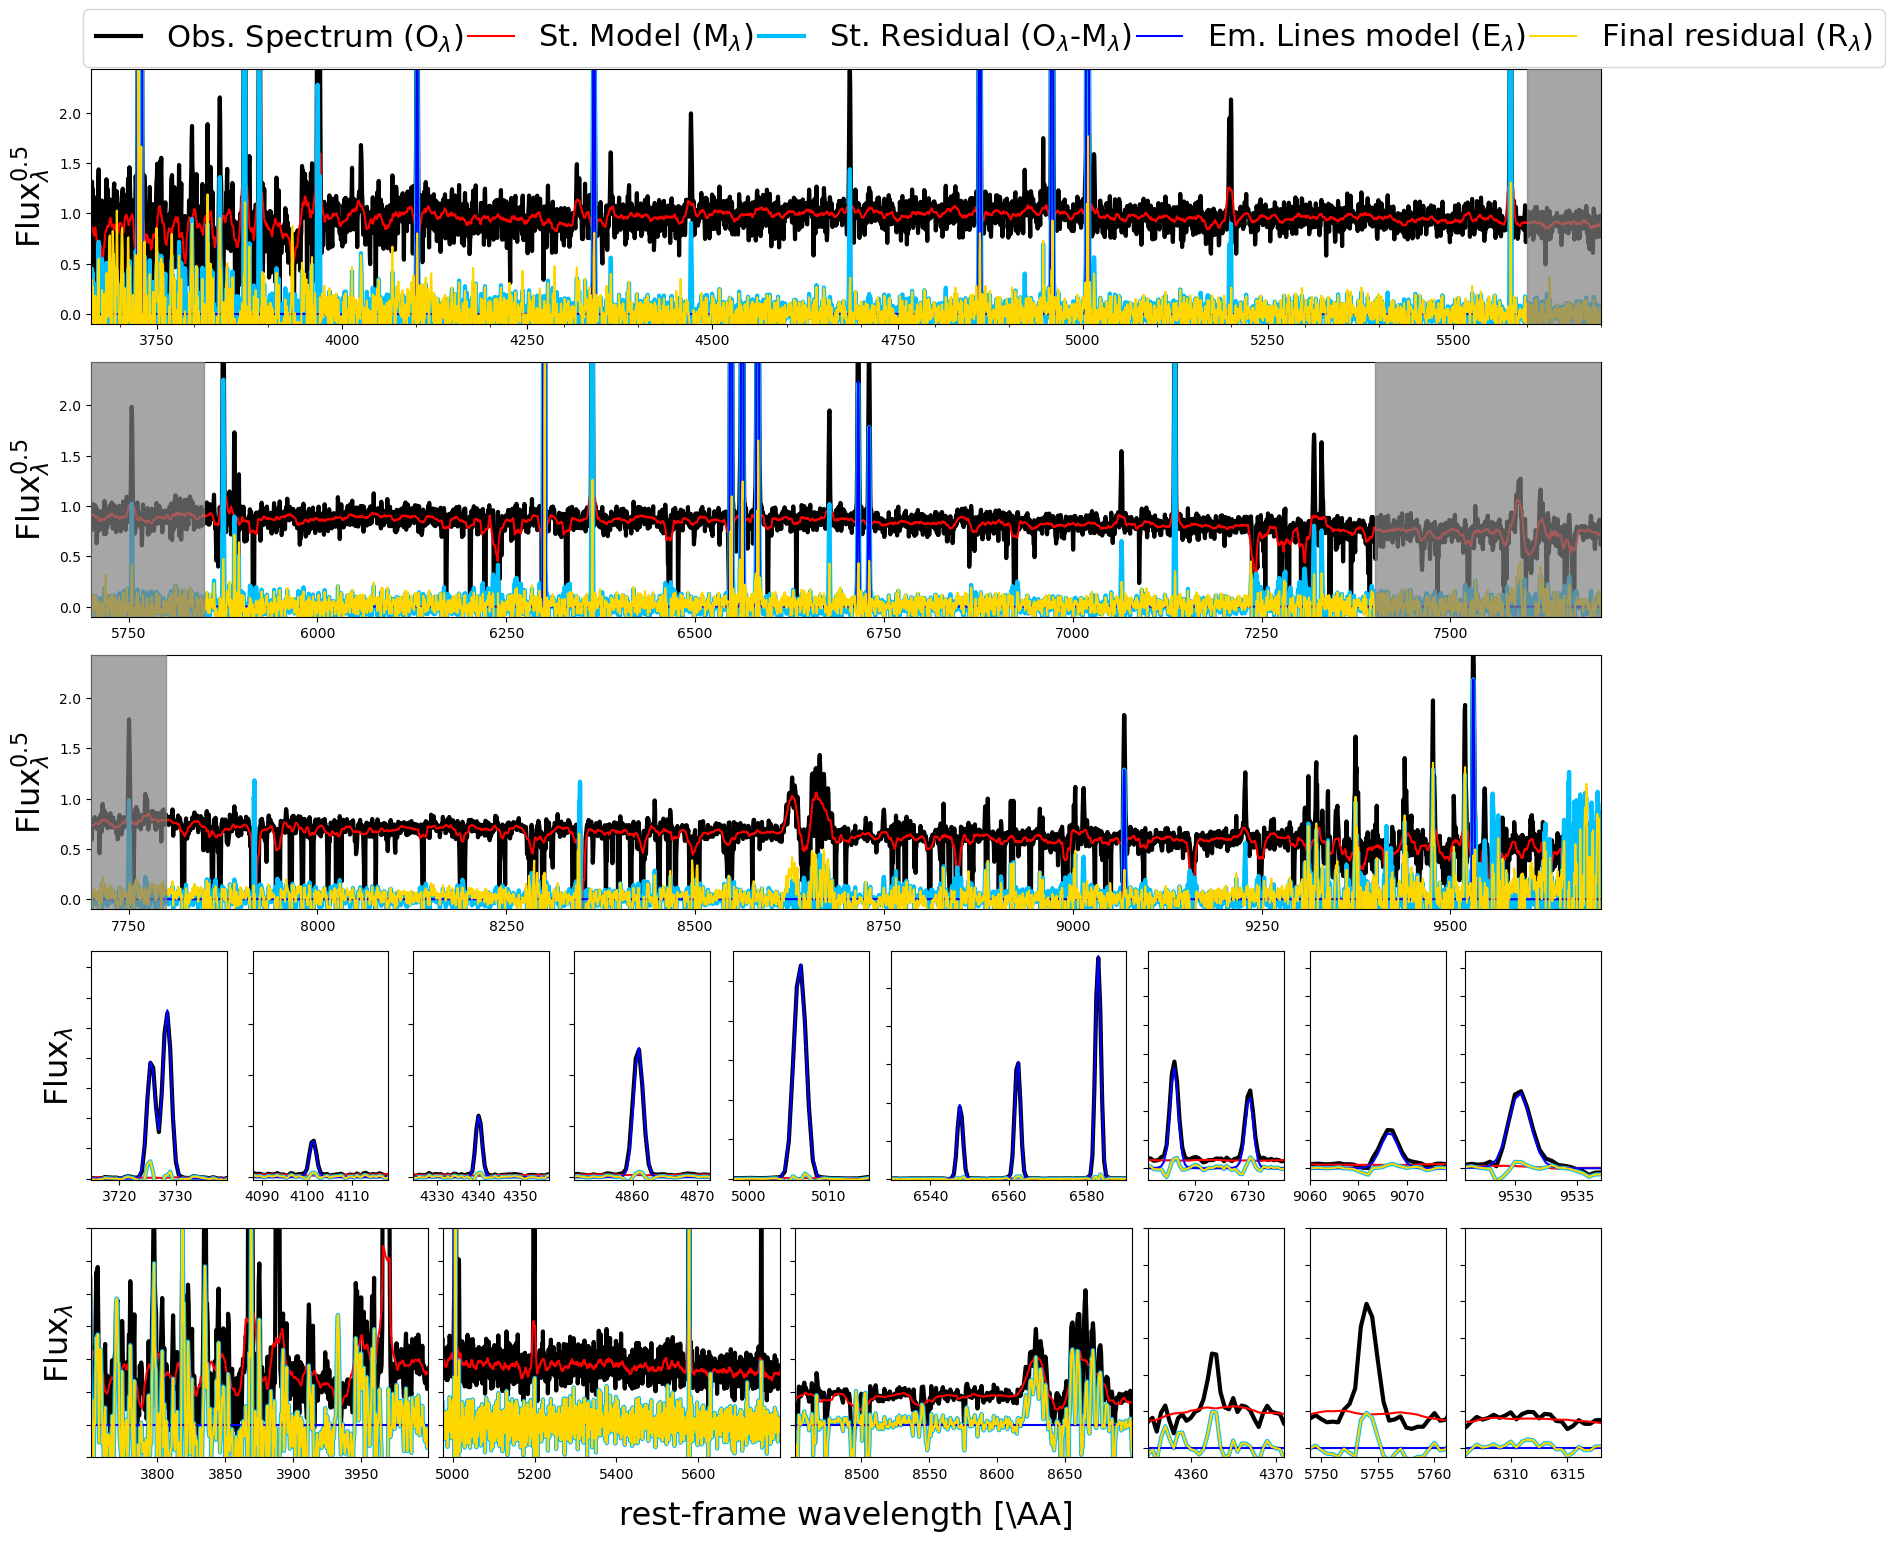

In [91]:
y_off = -2.27-1.09
y_off2 = -2.27-2.18
ranges = (3661,5700,7700,9700)
#ranges = (3600,3900,5700,7700,9700)
plot_spec_now_3pg(av_spec,wave,\
          name='Helix Nebulae',text='',c_map='CMRmap',output='figs/m_Helix_DR19.png',\
              insets=((0.00, y_off, 0.09, 0.9,3715,3739,-1,189,'[OII]'),\
                          (0.107, y_off, 0.09, 0.9,4088,4118,-1.0,89,r'H$\delta$'),\
                          (0.213, y_off, 0.09, 0.9,4324,4357,-1.0,89,r'H$\gamma$'),\
                          (0.320, y_off, 0.09, 0.9,4851,4872,-1.0,89,r'H$\beta$'),\
                          (0.425, y_off, 0.09, 0.9,4998,5015,-1.0,289,'[OIII]'),\
                          (0.530, y_off, 0.155, 0.9,6530,6590,-1,299,r'H$\alpha$+[NII]'),\
                          (0.700, y_off, 0.09, 0.9,6711,6737,-1.0,19,'[SII]'),\
                          (0.807, y_off, 0.09, 0.9,9060,9074,-1.0,19,'[SIII]'),\
                          (0.910, y_off, 0.09, 0.9,9526,9537,-1.0,19,'[SIII]'),\
                      (0.00, y_off2, 0.223, 0.9,3751,3999,-0.5,3,'3751-3999'),\
                      (0.233, y_off2, 0.223, 0.9,4976,5799,-0.5,3,'4976-5799'),\
                      (0.466, y_off2, 0.223, 0.9,8451,8699,-0.5,3,'8451-8699'),\
                      (0.700, y_off2, 0.09, 0.9,4363-8,4363+8,-0.25,6,'[OIII]'),\
                      (0.807, y_off2, 0.09, 0.9,5755-6,5755+6,-0.25,6,'[NII]'),\
                      (0.910, y_off2, 0.09, 0.9,6312-6,6312+6,-0.25,6,'[SIII]')
                     ),
                          y_min=-0.01,y_max=5.9,y0_d=0.3,y1_d=2.9,\
              x_min=(ranges[0],ranges[1],ranges[2]),x_max=(ranges[1],ranges[2],ranges[3]),plot_el=False,\
                plot_res=True,show_scale=False,n_ord=2,gamma=0.5,alpha=1.0, tab_el = None, SN_sc_lim=0.01)

## 11. Generate the final annotated average-spectrum figure

This cell calls `plot_spec_now_3pg` using the average model spectra computed above. The figure is designed to summarize the DR20 Helix model file in a publication-style format, with zoom-in insets around important diagnostic emission lines.

The insets include strong lines such as [O II], Hδ, Hγ, Hβ, [O III], Hα+[N II], [S II], and [S III], as well as weaker diagnostic features such as [O III] λ4363, [N II] λ5755, and [S III] λ6312. These regions are useful for checking whether the model reproduces both bright recombination/collisionally excited lines and fainter temperature-sensitive lines.